In [ ]:
import pandas as pd
import os
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/species_id_joined_k2_Bracken_updated_Jul26_latest.csv')
df

,panel,reference_species_id,Unnamed: 2
0,Anopheles stephensi,Anopheles stephensi,NaN
1,Anopheles stephensi,Anopheles stephensi,NaN
2,Anopheles stephensi,Anopheles stephensi,NaN
3,Anopheles stephensi,Anopheles stephensi,NaN
4,Anopheles stephensi,Anopheles stephensi,NaN
...,...,...,...
473,Anopheles coustani,Anopheles coustani,NaN
474,Anopheles coustani,Anopheles coustani,NaN
475,Anopheles coustani,Anopheles coustani,NaN
476,Anopheles coustani,Anopheles coustani,NaN


In [ ]:
import pandas as pd

# Create the crosstab using 'reference_species_id' and 'panel' columns from df
crosstab_df = pd.crosstab(df['reference_species_id'], df['panel'])

# Display the crosstab
print("Crosstab of reference_species_id vs panel:")
crosstab_df

Crosstab of reference_species_id vs panel:


panel,Anopheles arabiensis,Anopheles coluzzii,Anopheles coustani,Anopheles funestus,Anopheles gambiae,Anopheles stephensi
reference_species_id,,,,,,
Anopheles arabiensis,77,0,0,0,1,1
Anopheles coluzzii,0,69,0,0,11,0
Anopheles coustani,3,0,66,0,11,0
Anopheles funestus,1,0,0,79,0,0
Anopheles gambiae,3,1,0,0,76,0
Anopheles stephensi,1,0,0,0,0,78


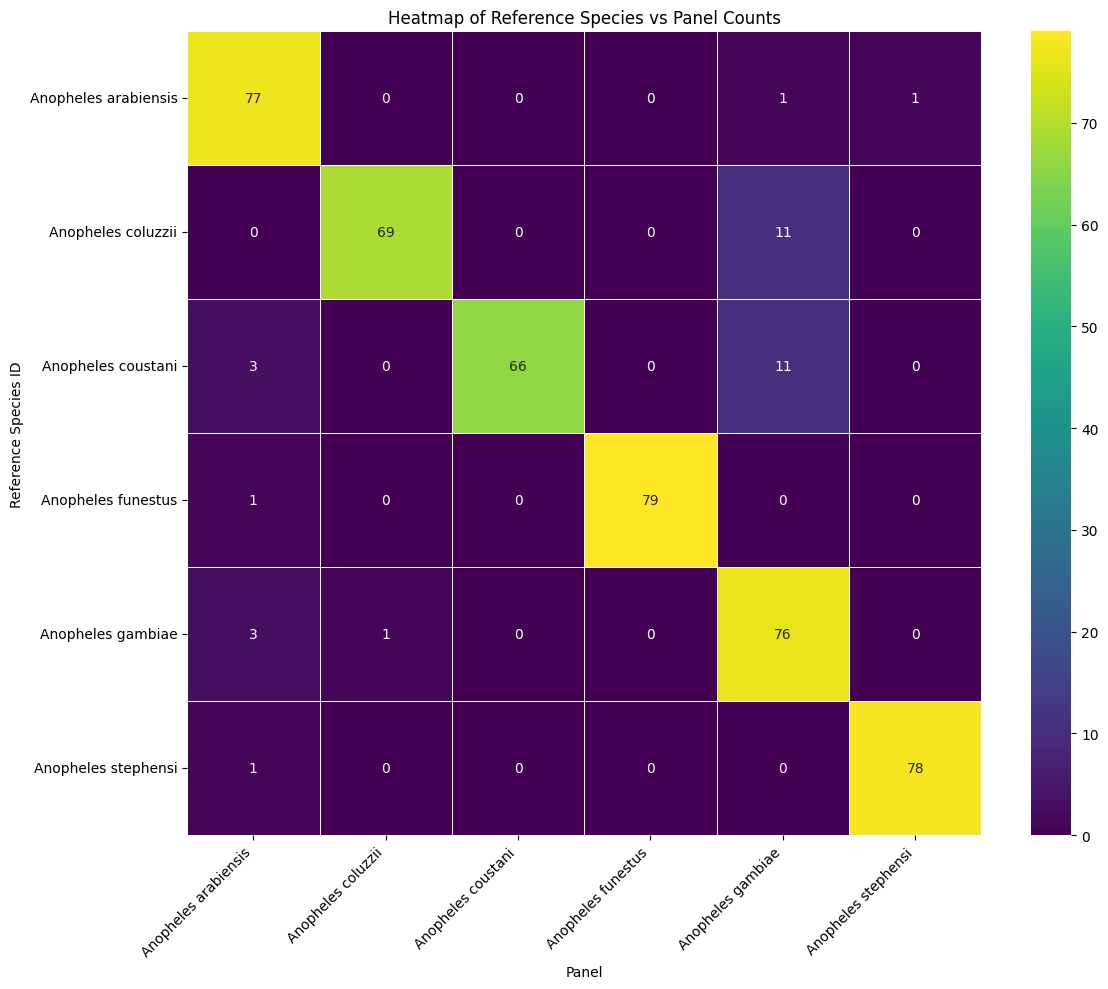

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Ensure all NaN values are filled with 0 and data is integer type for heatmap annotation
# Using crosstab_df as requested by the user
heatmap_data_crosstab = crosstab_df.fillna(0).astype(int)

plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(heatmap_data_crosstab, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Heatmap of Reference Species vs Panel Counts')
plt.xlabel('Panel')
plt.ylabel('Reference Species ID')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('crosstab_heatmap.png') # Save the plot as a PNG file
plt.show()

files.download('crosstab_heatmap.png') # Download the saved file

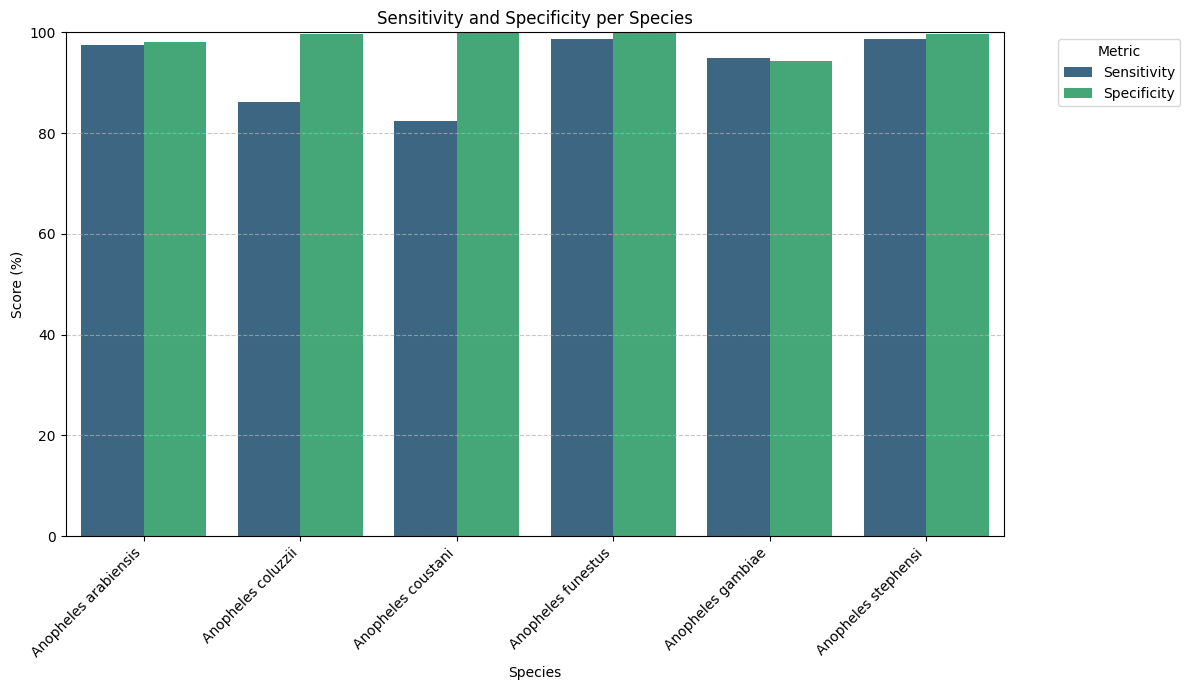

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import pandas as pd

# Assuming 'melted_results' DataFrame is available from previous execution
# It contains 'Species', 'Metric' (Sensitivity/Specificity), and 'Value' (scaled to 0-100).

# Calculate Sensitivity and Specificity from crosstab_df
results = []
total_sum = crosstab_df.sum().sum()

for species in crosstab_df.index:
    tp = crosstab_df.loc[species, species]
    fn = crosstab_df.loc[species, :].sum() - tp
    fp = crosstab_df.loc[:, species].sum() - tp
    tn = total_sum - tp - fn - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results.append({
        'Species': species,
        'Metric': 'Sensitivity',
        'Value': sensitivity * 100  # Scale to 0-100
    })
    results.append({
        'Species': species,
        'Metric': 'Specificity',
        'Value': specificity * 100  # Scale to 0-100
    })

melted_results = pd.DataFrame(results)

plt.figure(figsize=(12, 7)) # Adjust figure size for better readability
sns.barplot(x='Species', y='Value', hue='Metric', data=melted_results, palette='viridis')
plt.title('Sensitivity and Specificity per Species')
plt.xlabel('Species')
plt.ylabel('Score (%)') # Update label to reflect percentage scale
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100) # Set y-axis limit from 0 to 100
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot and then download it
plt.savefig('sensitivity_specificity_bar_graph.png')
plt.show() # Display the plot in the notebook
files.download('sensitivity_specificity_bar_graph.png')